In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 06

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

# PROBLEM 1
## Motion Under Inverse-Square Gravitational Force

We consider a particle moving under an attractive inverse-square potential:

$$
V(r) = -\frac{4\pi^2}{r}
$$
The corresponding force is:

$$
\vec{F}(r) = -\nabla V = -\frac{4\pi^2}{r^3} \vec{r}
$$



### Converting to First-Order System

Let:
- Position: $ (x, y) $
- Velocity: $ (v_x, v_y) $

Then the equations become:

$$
\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y
$$

$$
\frac{dv_x}{dt} = -\frac{4\pi^2 x}{r^3}, \quad
\frac{dv_y}{dt} = -\frac{4\pi^2 y}{r^3}
$$

where:

$$
r = \sqrt{x^2 + y^2}
$$


In [ ]:
def gravitational_system(t, y):
    x, y_pos, vx, vy = y
    r = np.sqrt(x**2 + y_pos**2)

    ax = -4 * np.pi**2 * x / r**3
    ay = -4 * np.pi**2 * y_pos / r**3

    return np.array([vx, vy, ax, ay])

## Choosing Initial Conditions

### Circular Orbit

For a circular orbit:
- Radius = 1
- Required velocity:

$$
v = 2\pi
$$

Initial condition:
$$
(x, y) = (1, 0), \quad (v_x, v_y) = (0, 2\pi)
$$

### Elliptical Orbit

To obtain an ellipse:
- Reduce velocity slightly below circular value.

Example:
$$
v_y < 2\pi
$$

This reduces energy → produces elliptical orbit.


### Key Insight

- **Velocity controls orbit shape**
- Higher velocity → more stretched orbit
- Exact velocity → circle

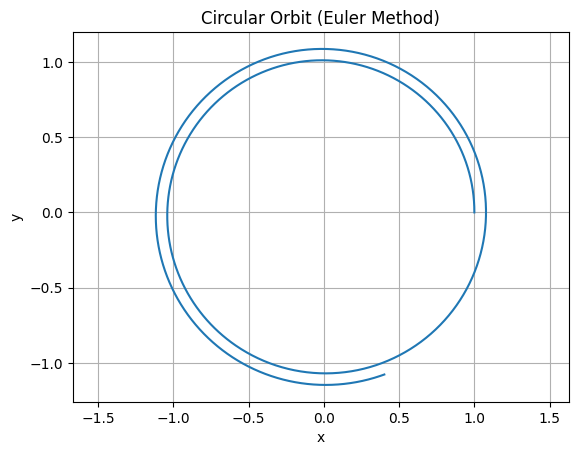

In [ ]:
# Time array
t = np.linspace(0, 2, 2000)

# Initial condition for circular orbit
y0_circular = np.array([1.0, 0.0, 0.0, 2*np.pi])

# Solve
sol_circular = euler(gravitational_system, y0_circular, t)

# Plot
plt.figure()
plt.plot(sol_circular[:,0], sol_circular[:,1])
plt.title("Circular Orbit (Euler Method)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid()
plt.show()

## Effect of Step Size (dt)

Euler's method is a **first-order numerical method**, meaning:
- Error is proportional to step size $dt $

We test three step sizes:
- Large dt → poor accuracy
- Medium dt → moderate accuracy
- Small dt → better accuracy


### Expectation

- Large dt → orbit spirals outward (energy increases artificially)
- Small dt → orbit stays closer to true shape

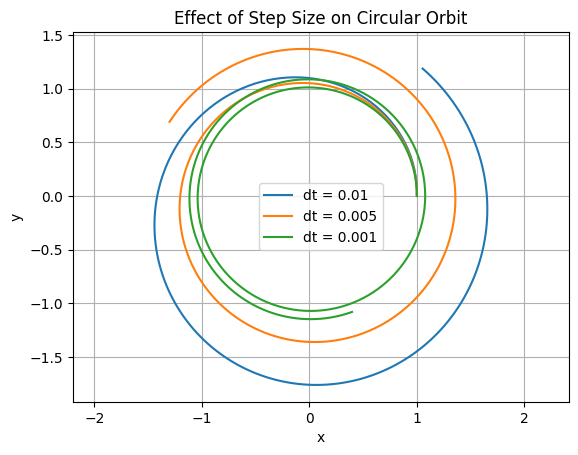

In [ ]:
step_sizes = [0.01, 0.005, 0.001]

plt.figure()

for dt in step_sizes:
    t = np.arange(0, 2, dt)
    y0 = np.array([1.0, 0.0, 0.0, 2*np.pi])

    sol = euler(gravitational_system, y0, t)

    plt.plot(sol[:,0], sol[:,1], label=f"dt = {dt}")

plt.title("Effect of Step Size on Circular Orbit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

## Observations and Analysis

### 1. Orbit Shapes

- When velocity = $ 2\pi $:
  - The orbit is nearly circular.
- When velocity is reduced:
  - The orbit becomes elliptical.

This matches theoretical predictions of gravitational motion.


### 2. Effect of Step Size

- For **large dt**:
  - Orbit deviates significantly.
  - Trajectory may spiral outward.
  - Energy is not conserved.

- For **smaller dt**:
  - Orbit becomes more stable.
  - Closer to true circular path.



### 3. Numerical Error in Euler Method

Euler method:
- Does **not conserve energy**
- Accumulates error over time
- Not ideal for long-term orbital simulations


### 4. Conclusion

- Euler method can qualitatively reproduce orbital motion.
- However, accuracy strongly depends on step size.
- Smaller step size improves results but increases computation cost.
- For better accuracy, higher-order methods (like Runge-Kutta) are preferred.

